Prediction (from scratch): [1]


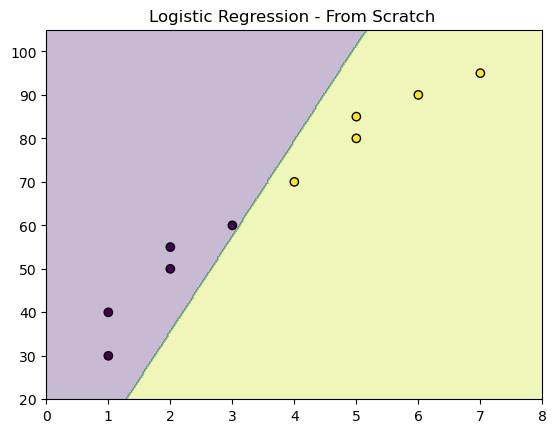

In [8]:
# I. REGRESSION LOGISTIC (Scratch)
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# FONCTION SIGMOÏDE
# =========================================================
# Cette fonction mathématique transforme n'importe quelle valeur réelle
# en une probabilité comprise entre 0 et 1.
# Elle est utilisée pour la classification binaire.

def sigmoid(z):
    # exp(-z) = exponentielle de -z
    # 1 / (1 + exp(-z)) donne une valeur entre 0 et 1
    return 1 / (1 + np.exp(-z))


# =========================================================
# DONNÉES
# =========================================================
# X : matrice des caractéristiques (features)
# chaque ligne = un étudiant
# chaque colonne = une variable (heures, présence)

X = np.array([[2, 50],[3, 60],[1, 30],[5, 80],[6, 90],[1, 40],[4, 70],[7, 95],[2, 55],[5, 85]])

# y : vecteur des labels (résultat réel)
# 1 = réussi, 0 = échoué
y = np.array([0, 0, 0, 1, 1, 0, 1, 1, 0, 1])


# =========================================================
# INITIALISATION DES PARAMÈTRES
# =========================================================

# nombre d'exemples (lignes) et de variables (colonnes)
n_samples, n_features = X.shape

# weights (poids) : coefficients associés à chaque feature
# initialisés à 0 (le modèle ne sait rien au début)
weights = np.zeros(n_features)

# bias (biais) : constante ajoutée au modèle
bias = 0

# learning rate : vitesse d’apprentissage
lr = 0.001

# nombre d’itérations (combien de fois on améliore le modèle)
epochs = 10000


# =========================================================
# ENTRAÎNEMENT DU MODÈLE
# =========================================================

for i in range(epochs):

    # -----------------------------------------------------
    # 1. MODÈLE LINÉAIRE
    # -----------------------------------------------------
    # z = XW + b
    # np.dot(X, weights) fait la somme :
    # w1*x1 + w2*x2 pour chaque ligne

    linear_model = np.dot(X, weights) + bias

    # -----------------------------------------------------
    # 2. APPLICATION DE LA SIGMOÏDE
    # -----------------------------------------------------
    # On transforme z en probabilité (entre 0 et 1)

    y_pred = sigmoid(linear_model)

    # -----------------------------------------------------
    # 3. CALCUL DES ERREURS (GRADIENTS)
    # -----------------------------------------------------
    # (y_pred - y) = erreur entre prédiction et réalité

    # dw : gradient par rapport aux poids
    dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))

    # db : gradient par rapport au biais
    db = (1 / n_samples) * np.sum(y_pred - y)

    # -----------------------------------------------------
    # 4. MISE À JOUR DES PARAMÈTRES
    # -----------------------------------------------------
    # On corrige les poids pour réduire l'erreur

    weights -= lr * dw
    bias -= lr * db

# =========================================================
# PRÉDICTION
# =========================================================

def predict(X):
    # calcul de z
    z = np.dot(X, weights) + bias
    # transformation en probabilité
    prob = sigmoid(z)
    # conversion en classe (0 ou 1)
    return [1 if p >= 0.5 else 0 for p in prob]

# =========================================================
# TEST
# =========================================================

new_student = np.array([[4, 75]])
print("Prediction (from scratch):", predict(new_student))

# =========================================================
# VISUALISATION
# =========================================================

# création d’une grille de points pour afficher la séparation
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 10, X[:, 1].max() + 10

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# calcul des prédictions pour chaque point de la grille
Z = sigmoid(np.dot(np.c_[xx.ravel(), yy.ravel()], weights) + bias)
Z = (Z > 0.5).astype(int)
Z = Z.reshape(xx.shape)

# affichage
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='black')
plt.title("Logistic Regression - From Scratch ")
plt.show()

Prediction (sklearn): [1]


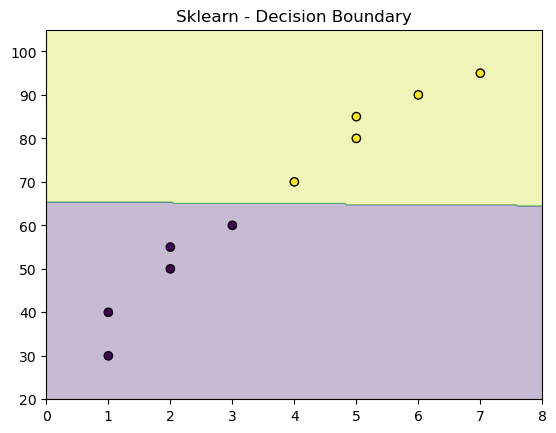

In [7]:
# I. REGRESSION LOGISTIC (Sklearn)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# =========================================================
# DONNÉES
# =========================================================

X = np.array([[2, 50],[3, 60],[1, 30],[5, 80],[6, 90],[1, 40],[4, 70],[7, 95],[2, 55],[5, 85]])

y = np.array([0, 0, 0, 1, 1, 0, 1, 1, 0, 1])


# =========================================================
# CRÉATION DU MODÈLE
# =========================================================

# Logistic Regression crée un modèle déjà optimisé
# Il contient automatiquement :
# - sigmoid
# - gradient descent (ou autre solver)
# - gestion des poids

model = LogisticRegression()


# =========================================================
# ENTRAÎNEMENT
# =========================================================

# fit() permet d’apprendre à partir des données
# le modèle ajuste automatiquement weights et bias

model.fit(X, y)


# =========================================================
# PRÉDICTION
# =========================================================

new_student = np.array([[4, 75]])

# predict() retourne directement 0 ou 1
print("Prediction (sklearn):", model.predict(new_student))


# =========================================================
# VISUALISATION
# =========================================================

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 10, X[:, 1].max() + 10

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),np.linspace(y_min, y_max, 300))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='black')
plt.title("Logistic Regression - Sklearn ")
plt.show()